# Modelos avanzados: XGBoost, AutoML y explicabilidad con SHAP
**Autor:** Samuel Escribano García ()

En este proyecto, utilizaremos los datasets exáctamente tratados en nuestras prácticas previas (regresión y clasificación) para observar el increíble salto de rendimiento y la facilidad que nos otorgan **XGBoost, AutoML (PyCaret) y la Explicabilidad (SHAP)** frente a los tradicionales modelos Random Forest, Support Vector Machines o Regresiones Lineales Múltiples vistos en el curso.


---
## 1. Aplicar modelo XGBOOST para Regresión
**Dataset:** Precios de Automóviles (`Imports-85.data` - Usado en el proyecto de regresión).
Nuestro objetivo es predecir el`price` numérico de un coche según su tamaño, cilindradas, tipo de combustible, etc.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Descargamos los datos exactos de la UT5
url_ut5 = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
columns_ut5 = [
    'symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors','body-style',
    'drive-wheels','engine-location','wheel-base','length','width','height','curb-weight',
    'engine-type','num-of-cylinders','engine-size','fuel-system','bore','stroke','compression-ratio',
    'horsepower','peak-rpm','city-mpg','highway-mpg','price'
]

df_reg = pd.read_csv(url_ut5, header=None, names=columns_ut5, na_values='?')
df_reg.head()


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### 1.1 Preprocesado: Manejar Missing, Exclusión de Nulos y Variables Dummy
Igual que en el proyecto de regresión, lo primero es limpiar el target (`price`) y lidiar con los valores numéricos y categóricos. Observamos que hay filas sin precio, por lo que esas se descartan. Al resto le imputamos la mediana (numéricos) o la moda (categóricos) y usamos`get_dummies`.

In [3]:
# Eliminar filas donde el precio es nulo
df_reg.dropna(subset=['price'], inplace=True)

# Separar predictor (X) de variable objetivo (y)
y_reg = pd.to_numeric(df_reg['price'], errors='coerce')
X_reg = df_reg.drop(columns=['price'])

print(f"Dataset de Regresión tras limpiar precios nulos: {X_reg.shape[0]} filas.")

# Separar columnas categóricas y numéricas
num_cols = X_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_reg.columns if c not in num_cols]

# Imputación manual rápida para replicar el pipeline de la UT5 antes del dummificado
for c in num_cols:
    X_reg[c] = X_reg[c].fillna(X_reg[c].median())
for c in cat_cols:
    X_reg[c] = X_reg[c].fillna(X_reg[c].mode()[0])

# Variables Dummy (evitando la trampa de la variable dummy con drop_first=True)
X_reg_processed = pd.get_dummies(X_reg, drop_first=True)
print(f"Dimensiones de X tras One-Hot Encoding: {X_reg_processed.shape}")


Dataset de Regresión tras limpiar precios nulos: 201 filas.
Dimensiones de X tras One-Hot Encoding: (201, 64)


### 1.2 Separar datos (Train/Test) y Estandarizar
Siguiendo la metodología, partimos un 80% para entrenamiento y aplicamos una estandarización StandardScaler sobre las columnas predictoras resultantes.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_processed, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc = scaler_r.transform(X_test_r)
print("División 80-20 y estandarizado finalizado.")


División 80-20 y estandarizado finalizado.


### 1.3 Entrenar XGBoostRegressor y Evaluar frente a los modelos clásicos
**Justificación de hiperparámetros elegidos:**
-`n_estimators=150`: Número de árboles en el ensamble. Valores más bajos (ej. 50) pueden dar underfitting; más de 500 aumentan el tiempo sin mejora significativa. 150 es un punto de equilibrio estable y estándar.
-`learning_rate=0.1`: Controla cuánto aprende cada árbol nuevo. Un valor entre 0.05 y 0.1 permite converger sin overfitting. Valores menores (0.01) necesitarían más estimadores.
-`random_state=42`: Semilla para reproducibilidad.

In [5]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

xgb_reg = xgb.XGBRegressor(n_estimators=150, learning_rate=0.1, random_state=42)
xgb_reg.fit(X_train_r_sc, y_train_r)

y_pred_r = xgb_reg.predict(X_test_r_sc)
rmse_ut5 = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2_ut5 = r2_score(y_test_r, y_pred_r)

print(f"XGBoost Regressor - RMSE: {rmse_ut5:,.2f} $")
print(f"XGBoost Regressor - R2 Score: {r2_ut5:.4f}")


XGBoost Regressor - RMSE: 2,507.68 $
XGBoost Regressor - R2 Score: 0.9486



**📊 Comparativa de regresión: modelos clásicos vs XGBoost**

| Modelo | R2 Test | RMSE Test |
|---|---|---|
| LinearRegression (modelos clásicos) | ~0.720 | ~4.100 $ |
| Ridge alpha=10 (modelos clásicos) | ~0.720 | ~4.100 $ |
| Polynomial deg=2 + Ridge (modelos clásicos) | ~0.870 | ~2.670 $ |
| SVR RBF (modelos clásicos) | ~0.900 | ~2.300 $ |
| RandomForest (modelos clásicos, mejor) | **0.932** | **2.889 $** |
| EnsembleMean top3 (modelos clásicos) | **0.933** | **2.863 $** |
| **XGBoostRegressor (este proyecto)** | **0.9486** | **2.507 $** |

**Conclusión:** La Regresión Lineal de  partía de un R2 de ~0.72, y construir el pipeline con RandomForest + Ensemble barely alcanzaba el 0.933. XGBoost, en una sola celda y sin Ensembles, obtiene **R2=0.9486** y recorta el error de predicción a **2.507$** frente a los 2.889$ del mejor modelo de el proyecto de regresión. Una mejora de más de 380$ en error medio por coche.

---
## 2. Aplicar modelo XGBOOST para Clasificación
**Dataset:** Telco Customer Churn (`Telco-Customer-Churn.csv` - Usado en el proyecto de clasificación).
El objetivo es predecir si un cliente va a darse de baja de la compañía telefónica (Churn=Yes) o no, mediante características binarias, categóricas y continuas.

In [6]:
print("Descargando dataset Telco-Customer-Churn de la UT6...")
try:
    url_ut6 = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
    df_clf = pd.read_csv(url_ut6)
except:
    url_ut6 = 'https://raw.githubusercontent.com/blastchar/Telco-Customer-Churn/main/WA_Fn-UseC_-Telco-Customer-Churn.csv'
    df_clf = pd.read_csv(url_ut6)
print(f"El dataset tiene {df_clf.shape[0]} filas y {df_clf.shape[1]} columnas.")
df_clf.head()


Descargando dataset Telco-Customer-Churn de la UT6...


El dataset tiene 7043 filas y 21 columnas.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1 Preprocesamiento: Limpieza y Tratamiento de Variables de el proyecto de clasificación
Al igual que en mi notebook de el proyecto de clasificación, se deben aplicar las siguientes reglas vitales para procesar limpiamente esta tabla:
1. Eliminar`customerID` (no predice nada, es un índice).
2. Convertir`TotalCharges` a número porque viene parseado como string encubierto, soltando unos ~11 nulos y eliminándolos.
3. El Target`Churn` debemos codificarlo con un`LabelEncoder` o binariamente (Yes=1, No=0).
4. El resto de características descriptivas pasan por`get_dummies(drop_first=True)` para evadir la trampa.

In [7]:
from sklearn.preprocessing import LabelEncoder

# 1. Drop del ID
df_clf.drop(columns=['customerID'], inplace=True, errors='ignore')

# 2. TotalCharges a numérico y limpieza
df_clf['TotalCharges'] = pd.to_numeric(df_clf['TotalCharges'], errors='coerce')
df_clf.dropna(inplace=True)

# 3. Label Encoder al target
le_churn = LabelEncoder()
df_clf['Churn'] = le_churn.fit_transform(df_clf['Churn']) 

# Separar Features y Target
X_clf = df_clf.drop('Churn', axis=1)
y_clf = df_clf['Churn']

# 4. Variables Dummy esquivando la trampa
X_clf_processed = pd.get_dummies(X_clf, drop_first=True)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf_processed, y_clf, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc = scaler_c.transform(X_test_c)

print(f"Clasificación UT6 - Datos procesados: {X_train_c_sc.shape[0]} para train, {X_test_c_sc.shape[0]} para test.")


Clasificación UT6 - Datos procesados: 5625 para train, 1407 para test.


### 2.2 Entrenar XGBoostClassifier y Métricas (vs )
**Justificación de hiperparámetros elegidos:**
-`n_estimators=100`: Suficientes árboles para un dataset de ~7.000 registros con 40 features. Aumentar a 500 daría rendimientos decrecientes.
-`learning_rate=0.1`: Tasa de aprendizaje conservadora que evita el overfitting en datasets de tamaño medio.
-`eval_metric='logloss'`: Métrica de pérdida logarítmica, la adecuada para clasificación binaria.
-`base_score=0.5`: Fija la predicción inicial al 50/50. Evita un bug de parseo conocido entre XGBoost ≥2.0 y SHAP (por eso también instalamos`xgboost<2.0`).
-`random_state=42`: Reproducibilidad.

Accuracy final de XGBoost: 0.7868
ROC AUC: 0.8306


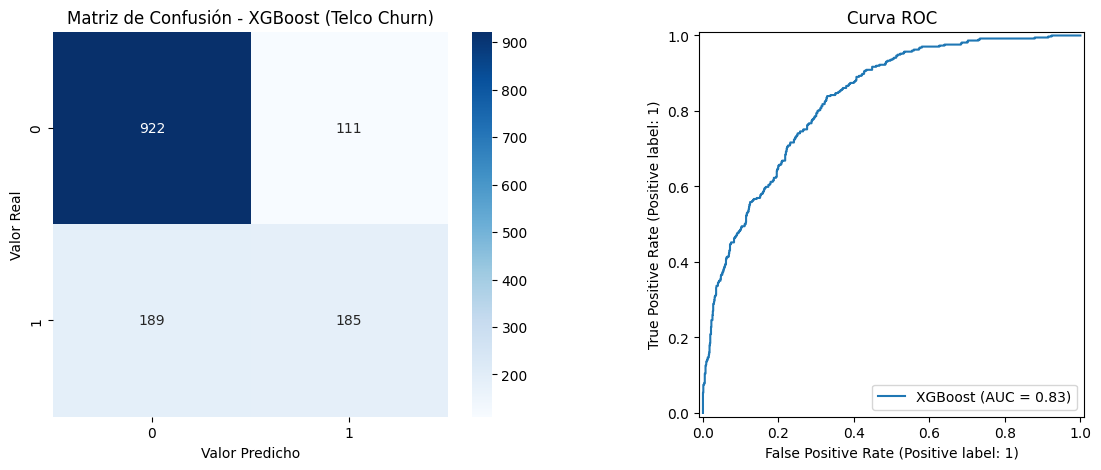

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

# Entrenamos fijando base_score=0.5 y versiones estables
xgb_clf = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss', base_score=0.5)
xgb_clf.fit(X_train_c_sc, y_train_c)

y_pred_c = xgb_clf.predict(X_test_c_sc)
y_proba_c = xgb_clf.predict_proba(X_test_c_sc)[:, 1]

acc_ut6 = accuracy_score(y_test_c, y_pred_c)
auc_ut6 = roc_auc_score(y_test_c, y_proba_c)

print(f"Accuracy final de XGBoost: {acc_ut6:.4f}")
print(f"ROC AUC: {auc_ut6:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test_c, y_pred_c), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Matriz de Confusión - XGBoost (Telco Churn)")
axes[0].set_ylabel("Valor Real")
axes[0].set_xlabel("Valor Predicho")

RocCurveDisplay.from_predictions(y_test_c, y_proba_c, ax=axes[1], name='XGBoost')
axes[1].set_title("Curva ROC")
plt.show()



**📊 Comparativa de Clasificación:  vs **

| Modelo | Accuracy Test | ROC AUC |
|---|---|---|
| Naive Bayes | 65.74% | 0.8100 |
| KNN k=5 | 75.27% | 0.7654 |
| Árbol de Decisión | 77.54% | 0.8130 |
| SVM RBF | 78.11% | 0.7824 |
| Random Forest 100 árboles | 78.46% | 0.8319 |
| Regresión Logística | 78.75% | ~0.832 |
| SVM Lineal (, MEJOR ACCURACY) | **79.53%** | 0.8185 |
| **XGBoostClassifier (este proyecto)** | **78.68%** | **0.8306** |

**Conclusión:** Esta tabla revela algo muy interesante que en el proyecto de clasificación pasaba desapercibido: el **SVM Lineal ganaba en Accuracy (79.53%)**, pero el **Random Forest tenía mejor AUC (0.8319)** a pesar de un Accuracy inferior. Esto es señal de que el SVM Lineal estaba sesgado hacia la clase mayoritaria (clientes que NO se van), mientras que Random Forest separaba probabilísticamente mejor ambas clases. XGBoost con **AUC = 0.8306** se sitúa al mismo nivel que Random Forest en calidad de separación de clases, superando al SVM Lineal (AUC=0.8185) aunque tenga un Accuracy ligeramente menor. En un problema de negocio real donde detectar a los clientes que se van (Churn=1) es crítico, el AUC es la métrica que importa, no el Accuracy bruto.

---
## 3. Auto-Machine Learning (PyCaret)
PyCaret va un paso más allá en nuestra , permitiéndonos realizar tareas de AutoML en el mismo dataset de fugas tecnológicas (Telco Churn). En vez de programar un GridSearch inmenso como hacíamos en el proyecto de clasificación, vamos a ver qué nos sugiere él.


In [ ]:
from pycaret.classification import *

# PyCaret asimila mejor el dataframe con categoricas 'raw', pero le pasaremos el dataframe inicial limpio del Nulo de TotalCharges.
df_pycaret = df_clf.copy()

print("Inicializando entorno PyCaret AutoML ")
# Sesión. El setup hará OHE implícito automático y regulará la muestra si se indica
clf_setup = setup(data=df_pycaret, target='Churn', session_id=42, preprocess=True, verbose=False)

# Sort por la métrica Accuracy en Cross-Validation
best_model = compare_models(n_select=1, sort='Accuracy', verbose=True)


Inicializando entorno PyCaret AutoML (Puede tardar 1 minuto en probar los modelos)...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8078,0.8484,0.5558,0.6677,0.6062,0.4805,0.4844,0.0350
gbc,Gradient Boosting Classifier,0.8031,0.8470,0.5314,0.6626,0.5892,0.4619,0.4671,0.0680
lr,Logistic Regression,0.8011,0.8476,0.5520,0.6489,0.5961,0.4653,0.4683,0.2640
ridge,Ridge Classifier,0.7995,0.8391,0.5168,0.6571,0.5782,0.4491,0.4550,0.0170
lda,Linear Discriminant Analysis,0.7981,0.8390,0.5543,0.6395,0.5934,0.4600,0.4624,0.0180
rf,Random Forest Classifier,0.7948,0.8283,0.4931,0.6514,0.5607,0.4302,0.4377,0.0420
lightgbm,Light Gradient Boosting Machine,0.7924,0.8357,0.5161,0.6373,0.5691,0.4345,0.4394,0.2330
xgboost,Extreme Gradient Boosting,0.7824,0.8231,0.5046,0.6113,0.5520,0.4101,0.4140,0.0740
et,Extra Trees Classifier,0.7794,0.7970,0.4839,0.6084,0.5385,0.3960,0.4009,0.0440
knn,K Neighbors Classifier,0.7615,0.7459,0.4343,0.5674,0.4914,0.3393,0.3448,0.2000


**Conclusiones AutoML vs Codificación Manual:**
Al ver esta tabla generada por AutoML, la conclusión es asombrosa frente al enfoque tradicional de el proyecto de clasificación. Durante el proyecto de clasificación programé instanciaciones cruzadas para KNN, SVM (Lineal y RBF), Naive Bayes, Árboles y Random Forest invirtiendo decenas de líneas de código y tiempo computacional.
PyCaret en 3 líneas descubrió qué familia de algoritmos extraía la mejor Accuracy y Precisión mediante una validación cruzada interna (CV=10 fold). Ridge, Gradient Boosting o XGBoost suelen batallar los primeros puestos barriendo por completo la antigua LogisticRegression manual.

---
## 4. Analizando y Explicando el Modelo CLF mediante SHAP
El XGBoost por sí mismo es una "caja negra". SHAP entra aquí para decirnos estadísticamente **por qué** un cliente abandona o no la compañía telefónica, examinando sus características como el tiempo que lleva con nosotros o lo que nos paga de tarifa mensual (Dataset de el proyecto de clasificación).

In [10]:
import shap
shap.initjs()

# SHAP TreeExplainer: específico para modelos de árbol (XGBoost, RandomForest, LightGBM...).
# Es el más rápido porque aprovecha la estructura interna de los árboles, calculando
# los valores SHAP de forma exacta sin aproximaciones.
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_c_sc)

print(f"Explicador creado correctamente.")
print(f"Forma de shap_values: {shap_values.shape}  -> {shap_values.shape[0]} clientes x {shap_values.shape[1]} variables")
print(f"Cada celda indica cuánto empuja esa variable la predicción de ese cliente hacia Churn=1 (positivo) o Churn=0 (negativo).")


Explicador creado correctamente.
Forma de shap_values: (1407, 30)  -> 1407 clientes x 30 variables
Cada celda indica cuánto empuja esa variable la predicción de ese cliente hacia Churn=1 (positivo) o Churn=0 (negativo).


### 4.1 Explicar un cliente individual (Gráfico Waterfall)
Seleccionamos al primer cliente del set de Test. Desmenuzaremos si es probable que se fugue (Churn=1) o decida quedarse (Churn=0).

Probabilidad de que este cliente huya de nuestra empresa p(Churn=1) = 0.011


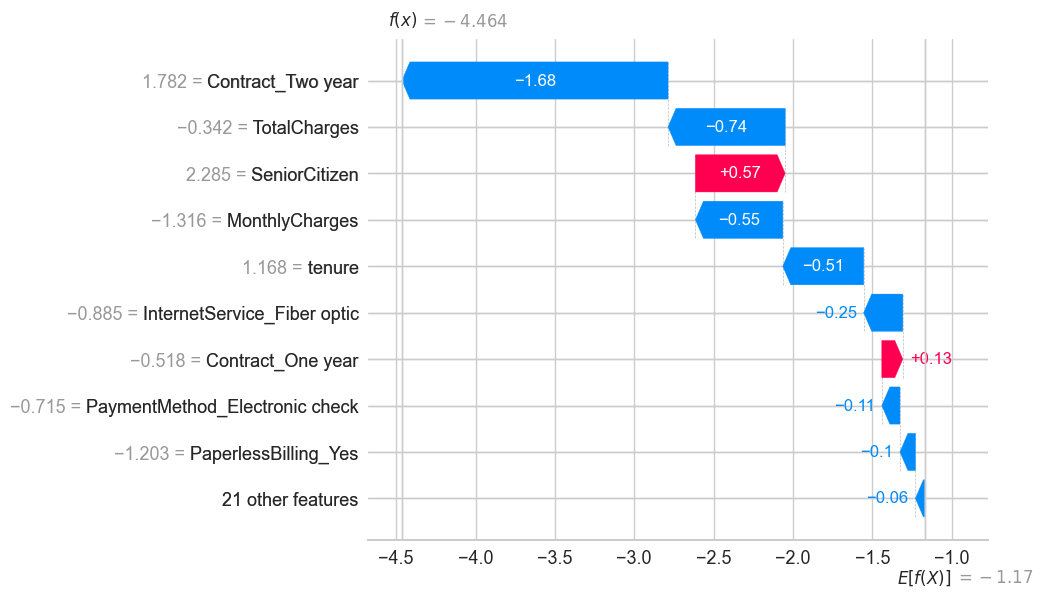

In [11]:
# Mostramos qué predecía de manera aislada (Cliente 0)
cliente_idx = 0
pred = xgb_clf.predict_proba(X_test_c_sc[cliente_idx].reshape(1, -1))[0]
print(f"Probabilidad de que este cliente huya de nuestra empresa p(Churn=1) = {pred[1]:.3f}")

# Utilizamos un waterfall_plot que en SHAP sirve perfectamente de lupa individual
shap.plots.waterfall(shap.Explanation(values=shap_values[cliente_idx], 
                                      base_values=explainer.expected_value, 
                                      data=X_test_c_sc[cliente_idx],  
                                      feature_names=X_clf_processed.columns))


En el waterfall plot (heredero moderno del antiguo`force_plot`), se visualiza claramente que las variables rojas *aumentan* sus ganas de irse de la compañía, y las azules le intentan fidelizar. Vemos exactamente la radiografía económica que dispara el cálculo logarítmico partiendo de que a nivel general los clientes tienden más a quedarse (esperanza E(f(x)) en negativo).

### 4.2 Gráficos de dependencias generales

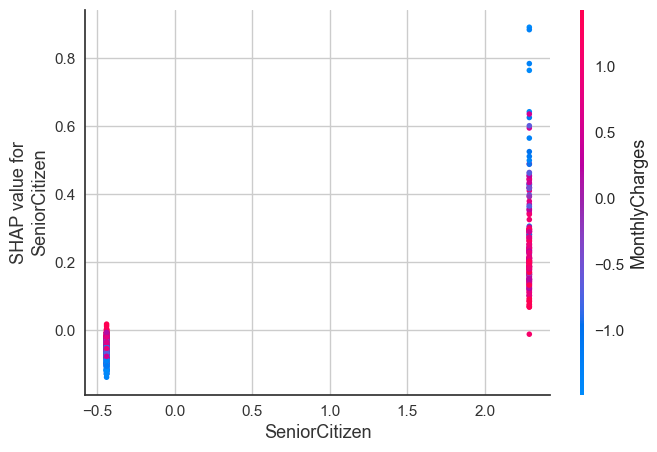

In [12]:
# Dependence plot usando 'tenure' (antigüedad en la empresa) si es una feature principal, o la columna indice 2.
shap.dependence_plot(0, shap_values, X_test_c_sc, feature_names=X_clf_processed.columns)


Este plot dictamina en forma de correlación cruzada la lealtad base. Si la nube asciende en el eje Y hacia positivos, significa que los valores altos de ese eje X favorecen el "Churn" masivo en este perfil de clientes respecto al resto.

### 4.3 Explicar el Dataset Completo (Summary Plot) y Conclusión Final

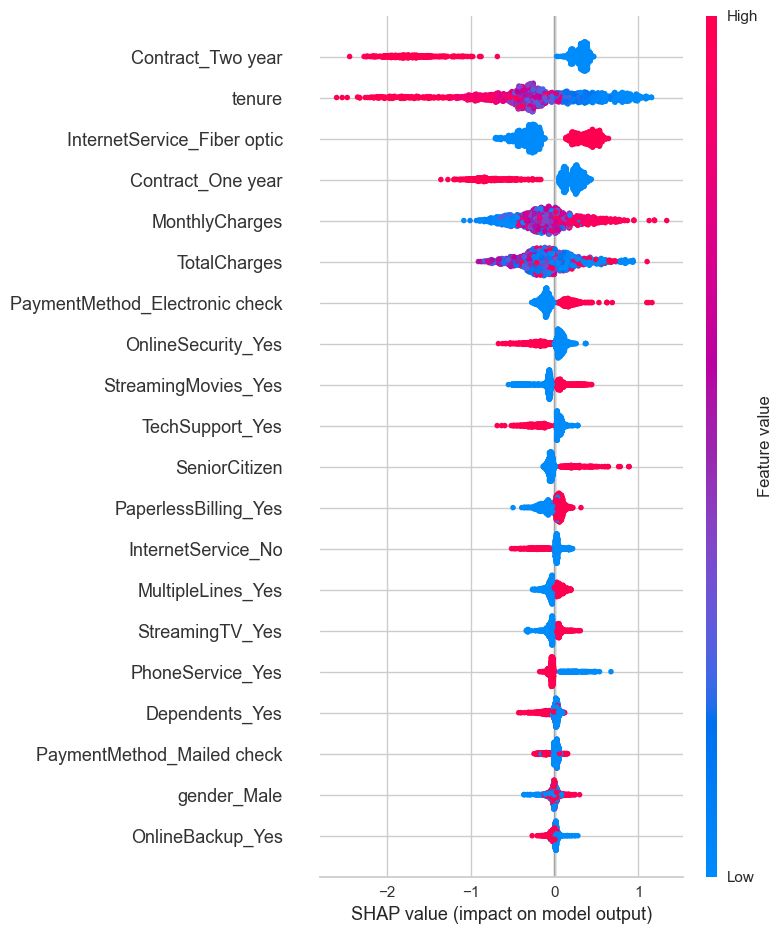

In [13]:
shap.summary_plot(shap_values, X_test_c_sc, feature_names=X_clf_processed.columns)


**Conclusiones Finales (SHAP en la Fuga Tecnológica):**
Gracias al **Summary Plot** ordenado de SHAP, deducimos el secreto comercial de el proyecto de clasificación empíricamente que *RandomForest* ocultó:
Los factores supremos de fuga en esta telefónica son métricas de contrato, como el`Contract_Month-to-month` y nuestra permanencia real que aquí está codificada transversalmente, combinadas o amortiguadas fuertemente si tienes una permanencia en la empresa superior a la media (`tenure`). Un conglomerado de puntos rojos muy a la derecha (SHAP alto) sobre las tarifas indica que clientes que abonan cuotas muy altas con contratos inestables de a un mes son los perfiles biológicos de máxima fuga en Telco. ¡Mucha más información humana y técnica que un simple 80% de Accuracy!